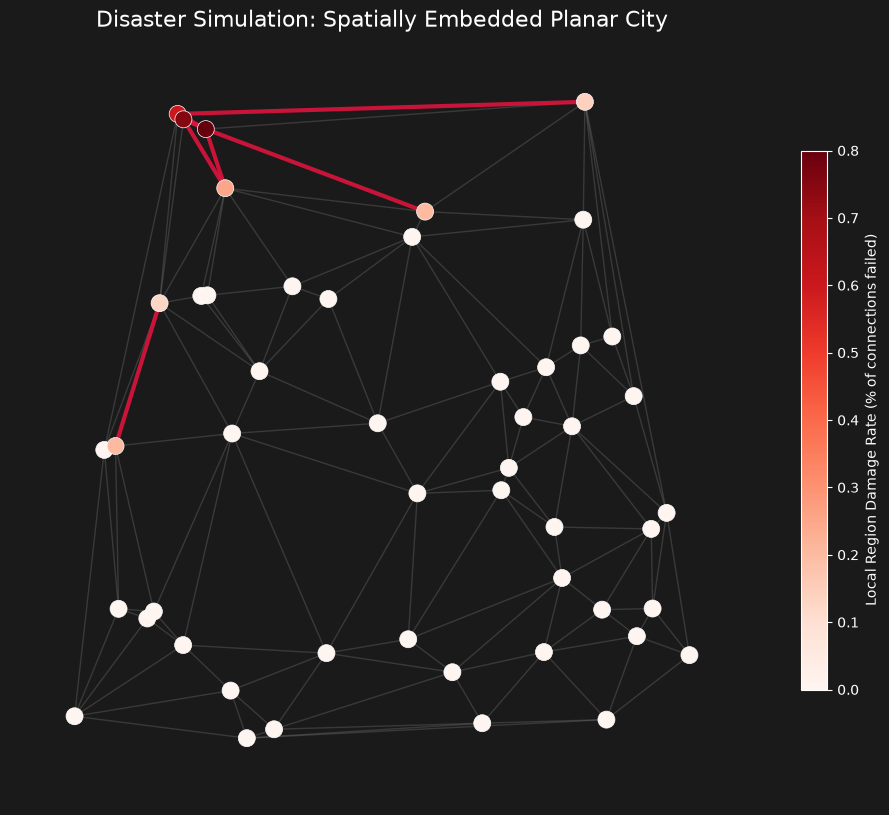

In [78]:
import networkx as nx
import numpy as np
from scipy.spatial import Delaunay
from scipy.spatial.distance import pdist, squareform
from scipy.stats import multivariate_normal, norm
import matplotlib.pyplot as plt

# ==========================================
# 1. GENERATE ORGANIC PLANAR CITY (DELAUNAY)
# ==========================================
N_NODES = 50
points = np.random.rand(N_NODES, 2)
pos = {i: (points[i, 0], points[i, 1]) for i in range(N_NODES)}

tri = Delaunay(points)
G = nx.Graph()
for simplex in tri.simplices:
    G.add_edge(simplex[0], simplex[1])
    G.add_edge(simplex[1], simplex[2])
    G.add_edge(simplex[2], simplex[0])

nx.set_node_attributes(G, pos, 'pos')

# ==========================================
# 2. CALCULATE EUCLIDEAN EDGE COVARIANCE
# ==========================================
unique_edges = sorted([tuple(sorted((u, v))) for u, v in G.edges()])
N_EDGES = len(unique_edges)

# Get physical midpoints of each edge
edge_midpoints = np.zeros((N_EDGES, 2))
for i, (u, v) in enumerate(unique_edges):
    x_u, y_u = pos[u]
    x_v, y_v = pos[v]
    edge_midpoints[i] = [(x_u + x_v) / 2.0, (y_u + y_v) / 2.0]

# Calculate pairwise physical distances and normalize
distance_matrix = squareform(pdist(edge_midpoints, metric='euclidean'))
max_dist = np.max(distance_matrix)
norm_distance_matrix = distance_matrix / max_dist if max_dist > 0 else distance_matrix

# Apply exponential decay
gamma = 4.0
sigma_sq = 1.0
cov_matrix = sigma_sq * np.exp(-gamma * norm_distance_matrix)

# PSD Projection to prevent LinAlgError
eigvals, eigvecs = np.linalg.eigh(cov_matrix)
eigvals[eigvals < 0] = 1e-8
safe_cov_matrix = eigvecs @ np.diag(eigvals) @ eigvecs.T
safe_cov_matrix = (safe_cov_matrix + safe_cov_matrix.T) / 2

# ==========================================
# 3. SIMULATE DISASTER
# ==========================================
edge_disaster_dist = multivariate_normal(mean=np.zeros(N_EDGES), cov=safe_cov_matrix)
edges_disaster_samples = edge_disaster_dist.rvs()

# Squash to [0, 1] range
edge_disaster_strength = norm.cdf(edges_disaster_samples)

# Map states back to graph (State 1 = Damage, State 0 = Safe)
for i, (u, v) in enumerate(unique_edges):
    strength = edge_disaster_strength[i]
    # Edges with a strength below 0.3 are considered "failed" (state = 1)
    G[u][v]['state'] = 1 if strength < 0.3 else 0

# ==========================================
# 4. CALCULATE REGIONAL IMPACT & PLOT
# ==========================================
node_damage_ratios = []
for n in G.nodes():
    total_roads = G.degree(n)
    failed_roads = sum(1 for neighbor in G.neighbors(n) if G[n][neighbor].get('state', 0) == 1)
    damage_ratio = failed_roads / total_roads if total_roads > 0 else 0
    node_damage_ratios.append(damage_ratio)

failed_edges = [(u, v) for u, v, d in G.edges(data=True) if d.get('state', 0) == 1]
safe_edges = [(u, v) for u, v, d in G.edges(data=True) if d.get('state', 0) == 0]

plt.figure(figsize=(12, 10))
ax = plt.gca()
ax.set_facecolor('#1a1a1a')
plt.gcf().set_facecolor('#1a1a1a')

# Nodes: Heatmap based on damage percentage
nodes = nx.draw_networkx_nodes(
    G, pos,  # Using the actual physical coordinates
    node_size=150,
    node_color=node_damage_ratios,
    cmap=plt.cm.Reds,
    edgecolors="white",
    linewidths=0.5
)

# Ghosted safe infrastructure
nx.draw_networkx_edges(
    G, pos,
    edgelist=safe_edges,
    edge_color='dimgray',
    width=1.0,
    alpha=0.4
)

# Highlighted damaged infrastructure
nx.draw_networkx_edges(
    G, pos,
    edgelist=failed_edges,
    edge_color='crimson',
    width=3.0,
    alpha=0.9
)

# Colorbar for regions
cbar = plt.colorbar(nodes, shrink=0.7)
cbar.set_label('Local Region Damage Rate (% of connections failed)', color='white')
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color='white')

for spine in ax.spines.values():
    spine.set_edgecolor('#1a1a1a')

plt.title("Disaster Simulation: Spatially Embedded Planar City", color='white', fontsize=16)
plt.axis('off')
plt.show()

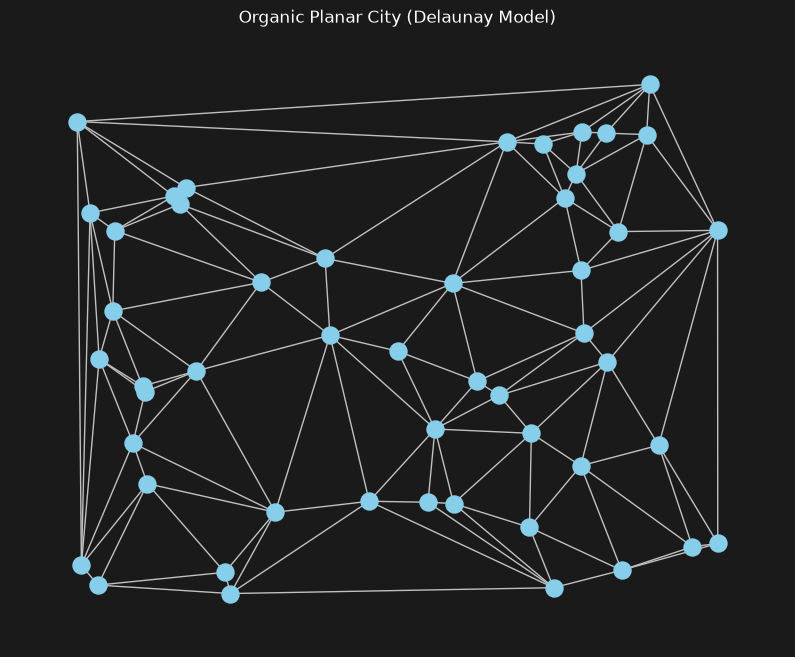

In [79]:
import networkx as nx
import numpy as np
from scipy.spatial import Delaunay
import matplotlib.pyplot as plt

N_NODES = 50

# 1. Generate random spatial (x, y) coordinates
points = np.random.rand(N_NODES, 2)
pos = {i: (points[i, 0], points[i, 1]) for i in range(N_NODES)}

# 2. Compute Delaunay Triangulation (Guaranteed connected & planar)
tri = Delaunay(points)

# 3. Build the NetworkX graph from the triangulation simplices (triangles)
G = nx.Graph()
for simplex in tri.simplices:
    G.add_edge(simplex[0], simplex[1])
    G.add_edge(simplex[1], simplex[2])
    G.add_edge(simplex[2], simplex[0])

# Attach the physical positions to the graph
nx.set_node_attributes(G, pos, 'pos')

# 4. Plot the realistic planar city
plt.figure(figsize=(10, 8))
nx.draw_networkx(G, pos, node_size=150, node_color="skyblue", edge_color="silver", with_labels=False)

ax = plt.gca()
ax.set_facecolor('#1a1a1a')
plt.gcf().set_facecolor('#1a1a1a')
plt.title("Organic Planar City (Delaunay Model)", color="white")
plt.axis('off')
plt.show()

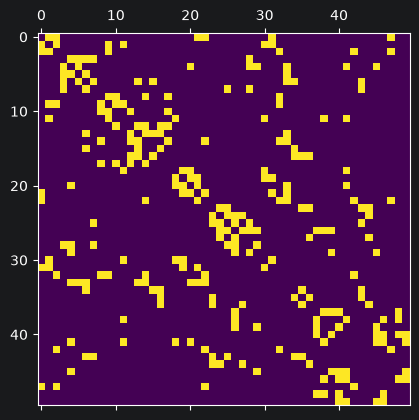

In [80]:
adj_matr = nx.adjacency_matrix(G).toarray()
plt.matshow(adj_matr)

In [81]:
MIN_EDGE_WEIGHT = 10
MAX_EDGE_WEIGHT = 50
# scipy.stats.uniform(loc, scale) draws from [loc, loc + scale], NOT [loc, high].
# Passing MAX_EDGE_WEIGHT directly as `scale` was drawing weights from [10, 60].
weight_dist = stats.uniform(MIN_EDGE_WEIGHT, MAX_EDGE_WEIGHT - MIN_EDGE_WEIGHT)
for u, v in G.edges():
    G[u][v]['weight'] = weight_dist.rvs(1)[0]


## Disaster Simulation

#### City Digital Twin

Each edge has an strength variable between 0-1.
Each edges strength is independent of each other --> might not also be

In [82]:
# Keyed by the same canonical (sorted) edge tuple that `unique_edges`/`edge_to_idx`
# use below, so these strengths line up with the right edges later on.
edge_strengths = {
    tuple(sorted((u, v))): s
    for (u, v, w), s in zip(edges, stats.uniform(0, 1).rvs(len(edges)))
}
edge_strengths


{(np.int32(5), np.int32(48)): np.float64(0.07858516359574697),
 (np.int32(2), np.int32(5)): np.float64(0.906235485141383),
 (np.int32(5), np.int32(44)): np.float64(0.8433767145014947),
 (np.int32(5), np.int32(6)): np.float64(0.32065669756321546),
 (np.int32(5), np.int32(20)): np.float64(0.32106535548831394),
 (np.int32(5), np.int32(19)): np.float64(0.5217027798758889),
 (np.int32(2), np.int32(48)): np.float64(0.8768202908902718),
 (np.int32(44), np.int32(48)): np.float64(0.8037004412357301),
 (np.int32(31), np.int32(48)): np.float64(0.39877974010150286),
 (np.int32(2), np.int32(10)): np.float64(0.23713106111302729),
 (np.int32(2), np.int32(33)): np.float64(0.07012692226973594),
 (np.int32(2), np.int32(6)): np.float64(0.5963539239069335),
 (np.int32(31), np.int32(44)): np.float64(0.3978932982981691),
 (np.int32(20), np.int32(44)): np.float64(0.37067833767230285),
 (np.int32(11), np.int32(44)): np.float64(0.43932049695308684),
 (np.int32(13), np.int32(44)): np.float64(0.3077711231269673)

In [83]:
pos

{0: (np.float64(0.27340503331039145), np.float64(0.6095626732760925)),
 1: (np.float64(0.67458054334086), np.float64(0.3222413523393821)),
 2: (np.float64(0.7526968154716334), np.float64(0.5128606941457287)),
 3: (np.float64(0.8501872933749293), np.float64(0.9863102657970295)),
 4: (np.float64(0.8455794505836113), np.float64(0.8908157099121782)),
 5: (np.float64(0.9135441861388288), np.float64(0.1063472303403119)),
 6: (np.float64(0.6379021510740351), np.float64(0.877099310510721)),
 7: (np.float64(0.7075957563721111), np.float64(0.028386222639569247)),
 8: (np.float64(0.6269145344725399), np.float64(0.39443466991293186)),
 9: (np.float64(0.9509539364905879), np.float64(0.7085946734786825)),
 10: (np.float64(0.6717804240885747), np.float64(0.14328854778514866)),
 11: (np.float64(0.10477272046578445), np.float64(0.22643989238120232)),
 12: (np.float64(0.8635047420111456), np.float64(0.29953744576144703)),
 13: (np.float64(0.7409245768470127), np.float64(0.8164617059883267)),
 14: (np.fl

In [84]:
import numpy as np
from scipy.stats import multivariate_normal, norm

# 1. Define N using 'unique_edges' to match the covariance matrix shape (135, 135)
N = len(unique_edges)

# 2. Project covariance matrix to the nearest Positive Semi-Definite (PSD) matrix
eigvals, eigvecs = np.linalg.eigh(cov_matrix)
eigvals[eigvals < 0] = 1e-8
safe_cov_matrix = eigvecs @ np.diag(eigvals) @ eigvecs.T
safe_cov_matrix = (safe_cov_matrix + safe_cov_matrix.T) / 2

# 3. Initialize the Multivariate Normal distribution
edge_disaster_dist = multivariate_normal(mean=np.zeros(N), cov=safe_cov_matrix)

# 4. Sample ONE disaster scenario for the whole network
edges_disaster_samples = edge_disaster_dist.rvs()

# 5. Squash the correlated raw values into a [0, 1] probability/strength range
edge_disaster_strength = norm.cdf(edges_disaster_samples)

In [91]:
edge_disaster_dist = multivariate_normal(mean=np.zeros(N_EDGES), cov=safe_cov_matrix)
edges_disaster_samples = edge_disaster_dist.rvs()

# Squash to [0, 1] range
edge_disaster_strength = norm.cdf(edges_disaster_samples)

# Map states back to graph (State 1 = Damage, State 0 = Safe)
for i, (u, v) in enumerate(unique_edges):
    disaster_strength = edge_disaster_strength[i]
    edge_strength= edge_strengths[(u,v)]
    G[u][v]['state'] = 1 if edge_strength <disaster_strength  else 0

KeyError: (np.int32(0), np.int32(11))

In [ ]:
# 4. Plot the realistic planar city
plt.figure(figsize=(10, 8))
nx.draw_networkx(G, pos, node_size=150, node_color="skyblue", edge_color="silver", with_labels=False)

ax = plt.gca()
ax.set_facecolor('#1a1a1a')
plt.gcf().set_facecolor('#1a1a1a')
plt.title("Organic Planar City (Delaunay Model)", color="white")
plt.axis('off')
plt.show()

In [ ]:
plt.hist(edge_disaster_strength)